In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Bengaluru_House_Data.csv")

print(df.columns)

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='str')


In [ ]:
import warnings


In [33]:
print(df.describe())

               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


In [34]:
print(df.head(10))
print(df.tail(10))

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   
5  Super built-up  Area  Ready To Move                Whitefield      2 BHK   
6  Super built-up  Area         18-May          Old Airport Road      4 BHK   
7  Super built-up  Area  Ready To Move              Rajaji Nagar      4 BHK   
8  Super built-up  Area  Ready To Move              Marathahalli      3 BHK   
9            Plot  Area  Ready To Move              Gandhi Bazar  6 Bedroom   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0

In [35]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB
None


In [ ]:
print("Unique values in categorical columns:")
print("area_type   :", df['area_type'].nunique())
print("availability:", df['availability'].nunique())
print("location    :", df['location'].nunique())
print("size        :", df['size'].nunique())
print("society     :", df['society'].nunique())

In [ ]:
print(df.isnull().sum())
# Society is something whihc needs to be looked on 

In [36]:
df = df.drop('society', axis=1)

In [37]:
df = df.drop('size', axis=1)

In [39]:
df['balcony'] = df['balcony'].fillna(df["balcony"].median())

In [40]:
df['bath'] = df['bath'].fillna(df["bath"].median())

In [60]:
def convert_sqft_to_num(x):
    try:
        if '-' in str(x):
            tokens = x.split('-')
            return (float(tokens[0]) + float(tokens[1])) /2
    except:
        return None

In [61]:
object_columns = df.select_dtypes(include=['object']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['area_type', 'availability', 'location', 'total_sqft'], dtype='str')

Numerical type columns:
Index(['bath', 'balcony', 'price'], dtype='str')


C:\Users\nihar\AppData\Local\Temp\ipykernel_18504\2676257866.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include=['object']).columns


In [62]:
df.duplicated().sum()


np.int64(577)

In [63]:
df.drop_duplicates()

,area_type,availability,location,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready To Move,Green Glen Layout,1715,3.0,3.0,112.00
13315,Built-up Area,Ready To Move,Whitefield,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,3600,5.0,2.0,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141,2.0,1.0,60.00


In [64]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype == 'object':
            if df[column].nunique() < 10:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']:
            if df[column].nunique() < 15:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [65]:
categorical_features, non_categorical_features, discrete_features, continuous_features = classify_features(df)
print(categorical_features, non_categorical_features, discrete_features, continuous_features)

[] [] ['balcony'] ['bath', 'price']


In [ ]:
# DATA VISUALIZATION

C:\Users\nihar\AppData\Local\Temp\ipykernel_18504\2408214624.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=i, data=df, palette='hls')


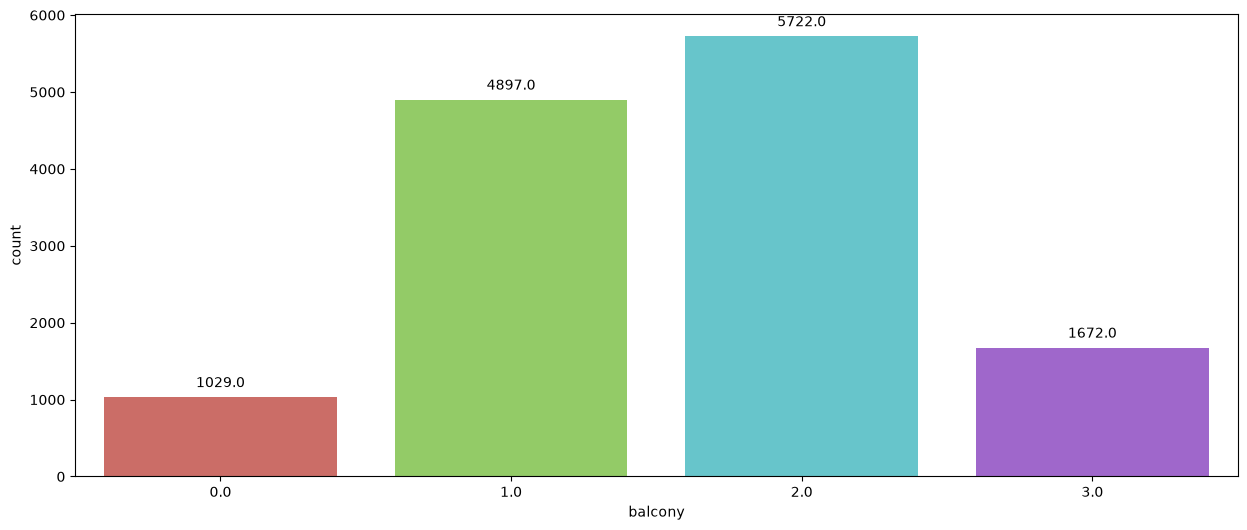

In [55]:
import seaborn as sns
for i in discrete_features:
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(x=i, data=df, palette='hls')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', 
                    xy=(p.get_x() + p.get_width() / 2., height),
                    xytext=(0, 10),  
                    textcoords='offset points',  
                    ha='center', va='center')  
    
plt.show()

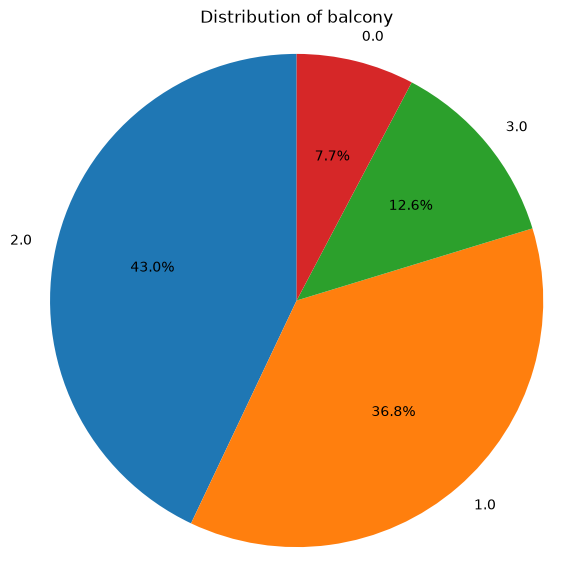

In [56]:
for i in discrete_features:
    counts = df[i].value_counts()
    
    plt.figure(figsize=(7, 7))
    plt.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(f'Distribution of {i}')
    plt.axis('equal')
    plt.show()

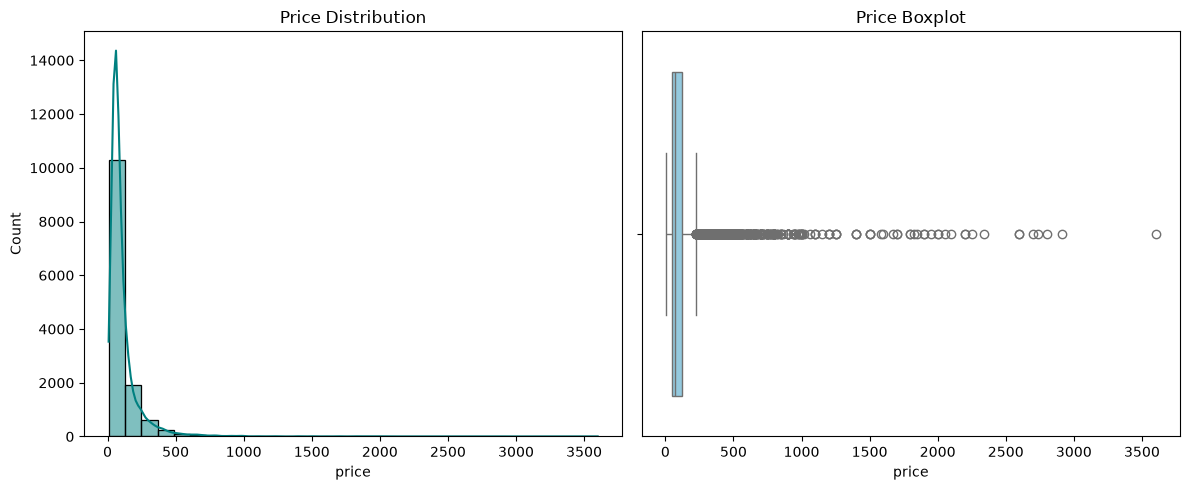

Price Skewness: 8.064


In [66]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='teal', bins=30)
plt.title('Price Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Price Boxplot')

plt.tight_layout()
plt.show()

print("Price Skewness:", round(df['price'].skew(), 3))

C:\Users\nihar\AppData\Local\Temp\ipykernel_18504\1328310836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='area_type', y='price', data=df, palette='hls')
C:\Users\nihar\AppData\Local\Temp\ipykernel_18504\1328310836.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='availability',y='price',data=df, palette='viridis')
C:\Users\nihar\AppData\Local\Temp\ipykernel_18504\1328310836.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='location', y='price',data=df, palette='magma')


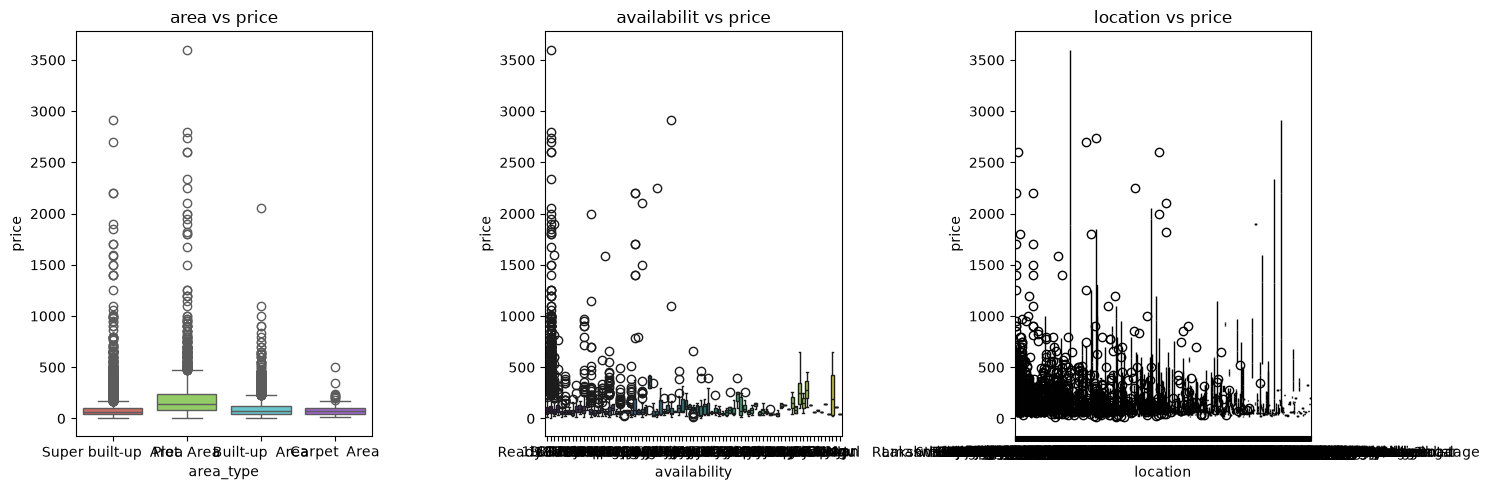

In [ ]:
# categorized vs continuous
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(x='area_type', y='price', data=df, palette='hls')
plt.title('area vs price')

plt.subplot(1,3,2)
sns.boxplot(x='availability',y='price',data=df, palette='viridis')
plt.title('availabilit vs price')

plt.subplot(1,3,3)
sns.boxplot(x='location', y='price',data=df, palette='magma')
plt.title('location vs price')

plt.tight_layout()
plt.show()


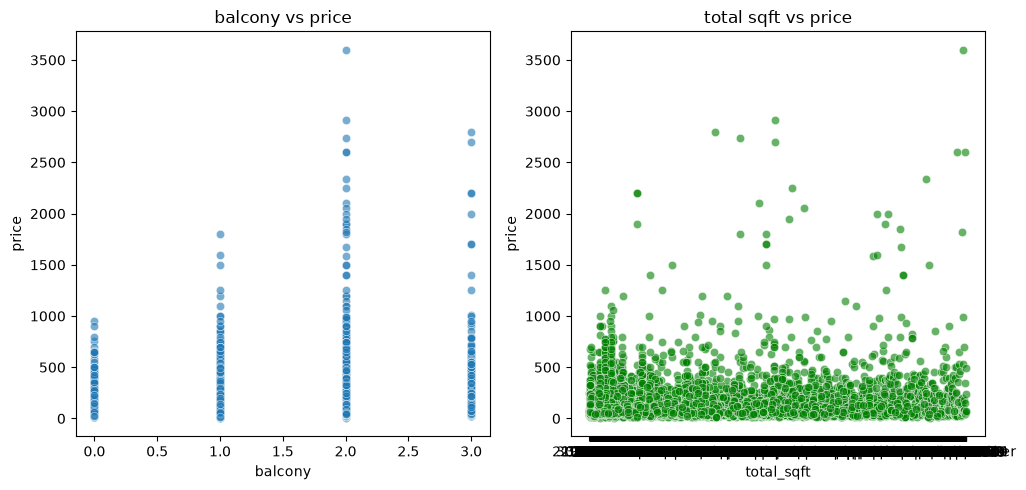

In [68]:
# Continuous vs continuos
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='balcony', y='price', data=df, alpha=0.6)
plt.title('balcony vs price')

plt.subplot(1, 3, 2)
sns.scatterplot(x='total_sqft', y='price', data=df, alpha=0.6, color='green')
plt.title('total sqft vs price')


plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(15,5))

sns.scatterplot(x='total_sqft', y='price', data=df, color='green')
plt.title('total sqft vs price')

plt.tight_layout()
plt.show()